# Semi-supervised GMM

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# from scipy.stats import norm
from scipy.stats import multivariate_normal
from scipy.fftpack import fft
from scipy.interpolate import make_splrep
from scipy.special import logsumexp

# from sklearn.mixture import GaussianMixture
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.utils import to_time_series_dataset
from tsfresh.feature_extraction import feature_calculators as feat_calc

import pyLasaDataset as lasa
# from hmmlearn import hmm
# from tqdm.auto import tqdm

Using LASA DataSet from /home/kir0ul/Projects/BayesDistanceClustering/.direnv/python-3.13/lib64/python3.13/site-packages/pyLasaDataset/resources/LASAHandwritingDataset/DataSet


### Hyperparameters

In [2]:
# seed = 0
seed = 42
seq_length = 1000
rng = np.random.default_rng(seed)
window_size = 30
window_step = 5

In [3]:
# max_iter = 300
# tol = 1e-6
beta = 0.5

## Data

In [4]:
# series1 = rng.normal(loc=0, scale=1, size=(seq_length, 2))
# series2 = rng.normal(loc=5, scale=1, size=(seq_length, 2))
# series3 = rng.normal(loc=-3, scale=1, size=(seq_length, 2))
# data = np.stack([series1, series2, series3])
# data.shape

In [5]:
means = np.array(
    [
        [1, 3],
        [3, 1],
        [2.5, 2.5],
    ]
)
covs = np.eye(2) * 0.08
data = np.ones((means.shape[0], seq_length, 2)) * np.nan
for idx in range(means.shape[0]):
    data[idx, :, :] = rng.multivariate_normal(
        mean=means[idx, :], cov=covs, size=(seq_length)
    )
data.shape

(3, 1000, 2)

In [6]:
K_components = data.shape[0]

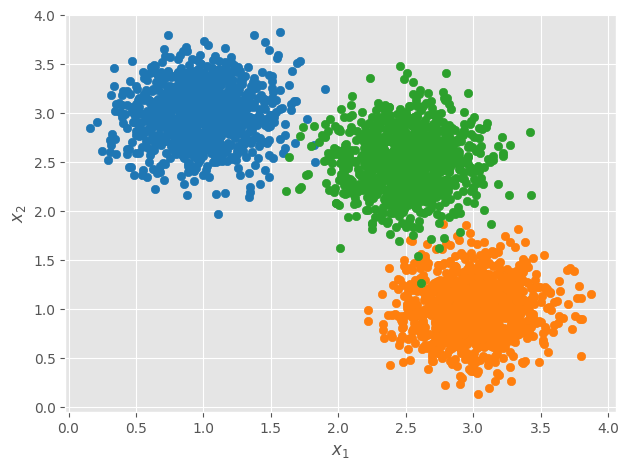

In [7]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(data.shape[0]):
        ax.scatter(data[idx, :, 0], data[idx, :, 1], color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

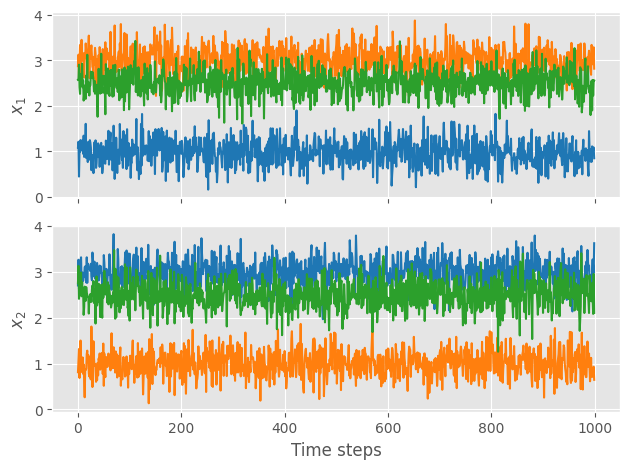

In [8]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(data.shape[-1], 1, sharex=True)
    for idx in range(data.shape[-1]):
        for jdx in range(data.shape[0]):
            ax[idx].plot(data[jdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

## Preprocessing & feature engineering

In [9]:
# dataset = to_time_series_dataset(data)
# dataset.shape

In [10]:
# scaler = TimeSeriesScalerMeanVariance()
# data_scaled = np.squeeze(scaler.fit_transform(data))
# data_scaled.shape

In [11]:
def sliding_window(series, window_size, step=1):
    windows = []
    for idx in range(0, len(series) - window_size + 1, step):
        windows.append(series[idx : idx + window_size])
    return np.array(windows)

In [12]:
windows = []
for idx in range(data.shape[0]):
    data_sc_i = data[idx, :, :]
    windows.append(
        sliding_window(series=data_sc_i, window_size=window_size, step=window_step)
    )
windows = np.array(windows)
windows.shape

(3, 195, 30, 2)

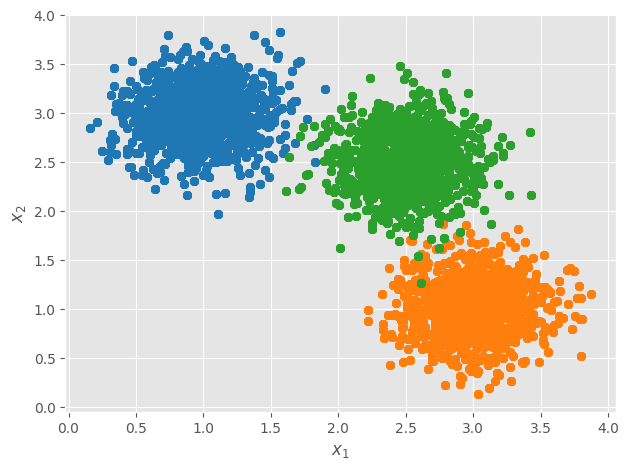

In [13]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        for jdx in range(windows.shape[1]):
            ax.scatter(
                windows[idx, jdx, :, 0], windows[idx, jdx, :, 1], color=cmap[idx]
            )
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

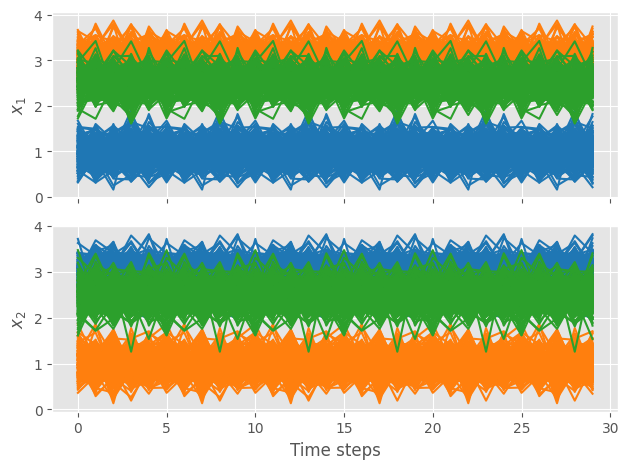

In [14]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            for kdx in range(windows.shape[1]):
                ax[idx].plot(windows[jdx, kdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [15]:
def loop_on_col(arr, funct, *args, **kwargs):
    res = []
    for col in range(arr.shape[1]):
        res.append(funct(arr[:, col], *args, **kwargs))
    return res

In [16]:
def extract_features(windows, lag=5, bins=10):
    features = []
    for win in windows:
        feats = [
            # np.mean(win),
            # np.std(win),
            # np.min(win),
            # np.max(win),
            # np.median(win),
            # np.percentile(win, 25),
            # np.percentile(win, 75),
            # *np.abs(fft(win)).flatten()[:5]
            *loop_on_col(arr=win, funct=feat_calc.abs_energy),
            feat_calc.absolute_sum_of_changes(win),
            feat_calc.autocorrelation(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.benford_correlation),
            # feat_calc.binned_entropy(x=win, max_bins=bins),
            feat_calc.c3(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.cid_ce, normalize=True),
            # *loop_on_col(arr=win, funct=feat_calc.fourier_entropy, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.kurtosis),
            *loop_on_col(arr=win, funct=feat_calc.lempel_ziv_complexity, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_above_mean),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_below_mean),
            feat_calc.mean_abs_change(win),
            *feat_calc.mean_change(win),
            *feat_calc.mean_second_derivative_central(win),
            *loop_on_col(
                arr=win,
                funct=feat_calc.percentage_of_reoccurring_datapoints_to_all_datapoints,
            ),
            *loop_on_col(
                arr=win, funct=feat_calc.percentage_of_reoccurring_values_to_all_values
            ),
            feat_calc.ratio_value_number_to_time_series_length(win),
            feat_calc.root_mean_square(win),
            feat_calc.sample_entropy(win),
            *loop_on_col(arr=win, funct=feat_calc.skewness),
            feat_calc.time_reversal_asymmetry_statistic(x=win, lag=lag),
            feat_calc.variation_coefficient(win),
            # ToDo: add curvature feature
        ]
        features.append(feats)
    return np.array(features)

In [17]:
features = []
for idx in range(windows.shape[0]):
    window_i = windows[idx, :, :]
    features.append(extract_features(window_i))
features = np.array(features)
features.shape

(3, 195, 33)

In [18]:
classes_gt = np.array(
    [np.ones(features.shape[1]) * idx for idx in range(features.shape[0])]
).flatten()
classes_gt

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [19]:
feat_mat = features.reshape(features.shape[0] * features.shape[1], features.shape[2])
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,33.690440,271.702596,59.013735,1.857398,0.732763,0.271055,14.064271,8.141350,8.041694,1.060411,...,0.0,0.0,0.0,1.0,2.256077,0.706084,-0.279155,0.131374,0.680455,0.499295
1,33.944338,276.476809,59.714259,1.919946,0.725301,0.258588,14.425081,7.660727,7.883395,0.508440,...,0.0,0.0,0.0,1.0,2.274574,0.714151,-0.125276,0.166432,0.254520,0.499662
2,31.483587,276.137907,60.953431,1.933680,0.645934,0.244815,14.368844,7.810017,8.142366,0.189753,...,0.0,0.0,0.0,1.0,2.264293,0.713957,0.167106,0.081023,0.076243,0.515267
3,29.991734,276.643455,61.784657,1.956840,0.611394,0.230027,14.392881,7.296700,8.107261,0.298802,...,0.0,0.0,0.0,1.0,2.260661,0.682024,0.284427,0.042131,-0.240625,0.524835
4,27.869338,271.188145,61.905676,1.972295,0.625856,0.258588,13.907280,6.981004,6.521838,-1.090308,...,0.0,0.0,0.0,1.0,2.232553,0.621299,-0.340506,-0.135537,-0.932258,0.534326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,191.224958,190.488915,11.244538,0.178186,0.402805,0.365971,15.704989,7.128651,6.901452,-0.079968,...,0.0,0.0,0.0,1.0,2.522280,0.638087,-0.058036,0.199396,-0.791043,0.129036
581,191.561368,192.317851,11.600275,0.130127,0.410930,0.365971,15.815842,7.119016,7.052014,-0.380038,...,0.0,0.0,0.0,1.0,2.529424,0.517943,0.046202,0.095414,-0.472010,0.133978
582,187.738024,189.590366,11.470342,0.085482,0.410930,0.365971,15.371213,7.407275,6.803567,-0.249846,...,0.0,0.0,0.0,1.0,2.507749,0.428996,0.229427,0.204408,0.191711,0.135852
583,180.304131,191.053720,11.362400,-0.052641,0.441857,0.365971,14.968082,6.973899,6.847757,-0.506392,...,0.0,0.0,0.0,1.0,2.487830,0.428996,-0.119955,0.124840,-0.005007,0.132153


In [20]:
# scaler = StandardScaler()
# feat_mat = scaler.fit_transform(feat_mat)
# feat_mat = pd.DataFrame(feat_mat)
# feat_mat

### Supervised data

In [21]:
# supervised_sample_size = 10
# idx_superv = np.random.choice(
#     np.arange(classes_gt.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(classes_gt[int(idx_val)])] = 1
# # Y = classes_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [22]:
def select_supervised_data(total_sample_size, labels_gt, K_components, U):
    unique_labels = np.unique(labels_gt)
    label_sample_size = int(np.round(total_sample_size / len(unique_labels)))

    # Select balanced data for each label
    all_idx = np.arange(labels_gt.shape[0])
    idx_superv = []
    for label in unique_labels:
        current_label_mask = labels_gt == label
        current_label_idx = np.array(
            [idx for idx in all_idx if current_label_mask[idx] == True]
        )
        assert len(current_label_idx) >= label_sample_size, (
            f"Not enough data points to select {label_sample_size} samples for class {label}, only {len(current_label_idx)} found"
        )
        idx_superv.extend(
            np.random.choice(current_label_idx, size=label_sample_size, replace=False)
        )
    idx_superv = np.array(idx_superv)

    # Build the Y matrix
    Y = np.zeros((len(idx_superv), K_components))
    for idxi, idx_val in enumerate(idx_superv):
        Y[idxi, int(labels_gt[int(idx_val)])] = 1

    X = U[idx_superv, :]
    return X, Y

In [23]:
supervised_sample_size = 10
X, Y = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=classes_gt,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((9, 33),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.]]))

## GMM clustering

In [24]:
def e_step(U, pi_mixing_prior, mu, Sigma, seed=None, allow_singular=False):
    """
    Compute the expectation step (equation 4).

    U: unlabeled training data
    """
    N = U.shape[0]
    K = pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            log_probs[n, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
                x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    gamma_resp = np.exp(log_probs - log_norm)
    return gamma_resp

In [25]:
def m_step(U, X, Y, gamma_resp, beta=0.5, reg_coef=1e-3):
    """
    Compute the maximization step.
    """
    assert X.shape[0] == Y.shape[0], "X and Y must have the same number of rows"
    assert U.shape[1] == X.shape[1], "U and X must have the same number of columns"
    M, D = X.shape
    N, _ = U.shape
    K = gamma_resp.shape[1]

    pi_mixing_prior_new = np.zeros(K) * np.nan
    mu_new = np.zeros((K, D)) * np.nan
    Sigma_new = np.zeros((K, D, D)) * np.nan

    for k in range(K):
        common_term = (1 - beta) * gamma_resp.sum(axis=0)[k] + beta * Y.sum(axis=0)[k]

        # Update mixing coefficients (equation 5)
        pi_mixing_prior_new[k] = common_term / ((1 - beta) * N + beta * M)

        # Update means (equation 6)
        gamma_resp_u = 0
        gamma_resp_x = 0
        for n in range(N):
            gamma_resp_u += gamma_resp[n, k] * U[n, :]
        for m in range(M):
            gamma_resp_x += gamma_resp[m, k] * X[m, :]
        mu_new[k, :] = ((1 - beta) * gamma_resp_u + beta * gamma_resp_x) / common_term

        # Update covariances (equation 7)
        gamma_resp_u_mu = 0
        gamma_resp_x_mu = 0
        for n in range(N):
            gamma_resp_u_mu += (
                gamma_resp[n, k] * (U[n, :] - mu_new[k]) * (U[n, :] - mu_new[k]).T
            )
        for m in range(M):
            gamma_resp_x_mu += (
                gamma_resp[n, k] * (X[m, :] - mu_new[k]) * (X[m, :] - mu_new[k]).T
            )
        # Sigma_new[k] = ((1 - beta) * gamma_resp_u_mu) / common_term + (
        #     beta * gamma_resp_x_mu
        # ) / common_term
        var = ((1 - beta) * gamma_resp_u_mu) / common_term + (
            beta * gamma_resp_x_mu
        ) / common_term
        # var = 1/2*(var + var.T)  # Semi Positive Definite issue
        # # regularization for numerical stability (optional, small jitter)
        # Sigma_new[k] += reg_coef*np.eye(D)

        # # Constrain the covariance matrices to be diagonal
        # var = (gamma_resp[:, k][:, None] * diff**2).sum(axis=0) / Nk[k]
        Sigma_new[k] = np.diag(var + reg_coef)
    return pi_mixing_prior_new, mu_new, Sigma_new

In [26]:
def log_likelihood(U, X, Y, pi_mixing_prior, mu, Sigma, beta=0.5, allow_singular=False):
    """
    Compute the log-likelihood (equation 9).
    """
    assert X.shape[0] == Y.shape[0], "X and Y must have the same number of rows"
    assert U.shape[1] == X.shape[1], "U and X must have the same number of columns"
    M, D = X.shape
    N, _ = U.shape
    K = pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))
    log_lik_unsuperv = np.zeros((N, K))
    log_lik_superv = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            log_probs[n, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
                x=U[n, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    log_lik_unsuperv = (1 - beta) * log_norm.sum(axis=0)

    for m in range(M):
        for k in range(K):
            # ToDo: may need to convert the multiplication by `Y[m, k]` to a sum of log
            log_lik_superv[m, k] = Y[m, k] * np.log(
                pi_mixing_prior[k]
            ) + multivariate_normal.logpdf(
                x=X[m, :], mean=mu[k], cov=Sigma[k], allow_singular=allow_singular
            )
    log_lik_superv = beta * log_lik_superv.sum()

    return log_lik_unsuperv + log_lik_superv

In [27]:
def run_EM(
    K_components,
    U,
    X,
    Y,
    beta=0.5,
    reg_coef=1e-3,
    max_iter=300,
    tol=1e-6,
    seed=None,
    allow_singular=False,
):
    """
    Expectation-Maximization algorithm.

    Implemented from [1].

    [1] Yan, H.-C., Zhou, J.-H., & Pang, C. K. (2017).
    Gaussian Mixture Model Using Semisupervised Learning for Probabilistic Fault Diagnosis Under New Data Categories.
    IEEE Transactions on Instrumentation and Measurement, 66(4), 723–733.
    https://doi.org/10.1109/TIM.2017.2654552

    """

    # Initialization
    N, D = X.shape
    pi_mixing_prior = np.ones(K_components) / K_components
    # pi_mixing_prior = np.random.uniform(size=K_components)
    # pi_mixing_prior = pi_mixing_prior/pi_mixing_prior.sum()
    # mu = np.random.rand(K_components, D) * 10.0
    kmeans_init = KMeans(n_clusters=K_components, random_state=seed).fit(X=X)
    mu = np.array(kmeans_init.cluster_centers_)
    # Sigma = np.array([np.eye(D) * rng.uniform(low=0, high=0.01, size=D) for _ in range(K_components)])
    Sigma = np.array([np.eye(D) for _ in range(K_components)])

    lls = []
    for it in range(max_iter):
        # E-step
        gamma_resp = e_step(
            U=U, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
        )

        # M-step
        pi_mixing_prior, mu, Sigma = m_step(
            U=U, X=X, Y=Y, gamma_resp=gamma_resp, reg_coef=reg_coef
        )

        # Log-likelihood
        ll = log_likelihood(
            U=U,
            X=X,
            Y=Y,
            pi_mixing_prior=pi_mixing_prior,
            mu=mu,
            Sigma=Sigma,
            allow_singular=allow_singular,
        )
        lls.append(ll)

        # Logging during training
        if it % 10 == 0:
            # plot_gmm(X, mu, Sigma, title=f'GMM Contours — Iteration {it+1}')
            print(f"Iteration {it}/{max_iter} -- Log-likelihood: {ll[0]}")

        # Convergence check
        if it > 0 and abs(lls[-1] - lls[-2]) < tol:
            print(f"\n--- Converged at iteration {it + 1} ---\n")
            break

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots()
        ax.plot(lls, marker=".", c="k")
        ax.set_title("EM training")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Log-likelihood")
        # ax.set_grid(True, alpha=0.3)
        plt.show()

    labels_pred = np.argmax(gamma_resp, axis=1)
    return mu, Sigma, gamma_resp, labels_pred, pi_mixing_prior

In [28]:
def predict(U, pi_mixing_prior, mu, Sigma, seed=None):
    gamma_resp = e_step(
        U=U, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
    )
    labels_pred = np.argmax(gamma_resp, axis=1)
    return gamma_resp, labels_pred

Iteration 0/300 -- Log-likelihood: -5022.238136908794

--- Converged at iteration 2 ---



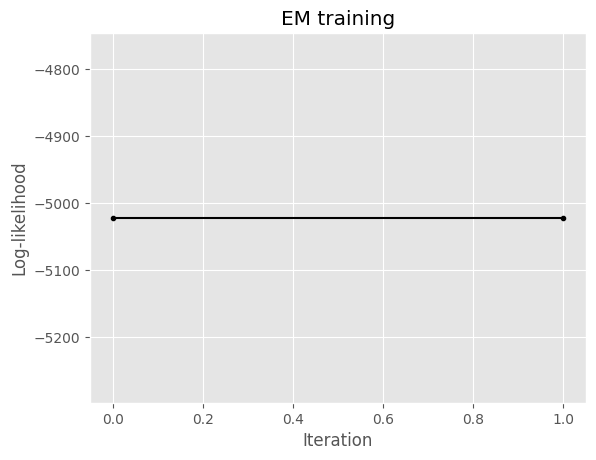

In [30]:
reg_coef = 1e-5
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [31]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 2.68978578e+02,  3.23108318e+01,  5.90093105e+01,
          1.81768003e+00,  2.59287870e-01,  6.42683596e-01,
          1.38444960e+01,  7.68206144e+00,  7.74904193e+00,
         -8.98452299e-02,  9.44198736e-02,  6.04377104e-01,
          6.04545455e-01,  4.37373737e+00,  4.11616162e+00,
          4.11616162e+00,  4.27777778e+00,  1.96697702e+00,
          1.04442429e-03, -1.18853789e-03,  4.79757036e-05,
          3.47518056e-04,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  9.84848485e-01,
          2.22348887e+00,  8.16010447e-01,  7.13467161e-02,
         -1.99068107e-02, -6.14367889e-03,  5.09159246e-01],
        [ 3.82976189e+01,  2.73886804e+02,  6.13824672e+01,
          1.87720893e+00,  6.22892666e-01,  2.78335599e-01,
          1.42804122e+01,  7.84910741e+00,  7.94721743e+00,
         -6.57858546e-02,  4.05551242e-04,  6.34175084e-01,
          6.34848485e-01,  4.39898990e+00,  4.66666667e+00,
          4.47979798e+00,  3.91414141e+

In [32]:
# with plt.style.context("ggplot"):
#     cmap = plt.colormaps["tab10"].colors
#     fig, ax = plt.subplots()
#     for idx in range(data.shape[0]):
#         ax.scatter(data[idx, :, 0], data[idx, :, 1], color="k", alpha=0.4)
#     ax.set_xlabel(f"$x_1$")
#     ax.set_ylabel(f"$x_2$")

#     # xg, yg = np.meshgrid(np.linspace(-5, 15, 100), np.linspace(-5, 15, 100))
#     # pos = np.dstack((xg, yg))
#     # for jdx in range(K_components):
#     #     rv = rng.multivariate_normal(
#     #         mean=gmm.means_[jdx], cov=gmm.covariances_[jdx]
#     #     )
#     #     # ax.contour(xg, yg, rv.pdf(pos), levels=5, colors=cmap[jdx], alpha=0.8)
#     #     ax.scatter(gmm.means_[jdx, 0], gmm.means_[jdx, 1], c="k")#, color=cmap[jdx], marker="x", s=100)

#     fig.tight_layout()
#     plt.show()

### Metrics

In [33]:
# accu = accuracy_score(y_true=classes_gt, y_pred=clust_labels_pred)
# print(f"Accuracy: {accu}")

In [34]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.9245119863149125
Completeness: 1.0
Fowlkes-Mallows index: 1.0
Homogeneity: 1.0
Mutual Information: 1.09861228866811
Adjusted mutual information: 1.0
Normalized Mutual Information: 1.0
Rand index: 1.0
Adjusted rand index: 1.0
V-measure: 1.0


In [35]:
def plot_cluster_res(U, X, Y, labels_gt, labels_pred, gamma_resp, mu):

    # Transform data to first two principal components for plotting
    pca = PCA(n_components=2)
    U_pca = pca.fit_transform(U)
    X_pca = pca.transform(X)
    mu_pca = pca.transform(mu)

    uncertainty = 1 - gamma_resp.max(axis=1)

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
        ax[0].scatter(U_pca[:, 0], U_pca[:, 1], c=labels_gt, alpha=0.5, s=20)
        ax[0].scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            marker="+",
            c="k",
            alpha=0.5,
            s=20,
            label="Supervised data",
        )
        ax[0].set_title("True clusters")
        ax[1].scatter(U_pca[:, 0], U_pca[:, 1], c=labels_pred, alpha=0.5, s=20)
        ax[1].scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            marker="+",
            c="k",
            alpha=0.5,
            s=20,
            label="Supervised data",
        )
        ax[1].scatter(
            mu_pca[:, 0],
            mu_pca[:, 1],
            marker="X",
            c="r",
            alpha=1,
            s=50,
            label=r"$\mu$",
        )
        ax[1].set_title("Predicted clusters")
        ax[2].scatter(U_pca[:, 0], U_pca[:, 1], c=uncertainty, alpha=0.5, s=20)
        ax[2].set_title("Uncertainty")
        for axi in ax:
            axi.set_xlabel("PC 1")
            axi.set_ylabel("PC 2")
        for axi in ax[:2]:
            axi.legend(loc="best")
        for axi in ax[:2]:
            axi.legend(loc="best")
        fig.tight_layout()
        plt.show()

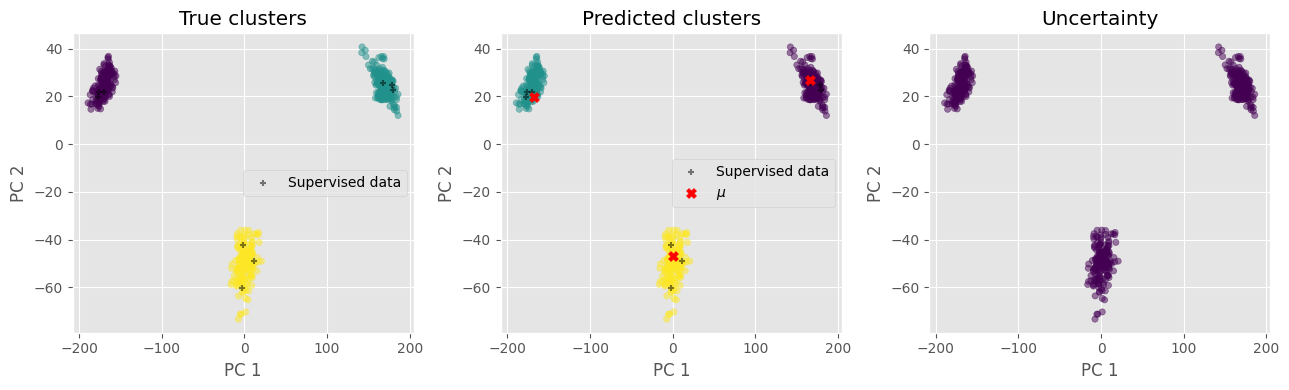

In [36]:
plot_cluster_res(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=classes_gt,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

### New data

In [37]:
# new_data = np.random.normal(6, 1, 70)
# new_feat = np.array([np.mean(new_data), np.std(new_data)])[np.newaxis, :]
# new_feat

In [38]:
new_data = rng.multivariate_normal(
    mean=np.array([6, 1]), cov=covs, size=(seq_length * 2)
)
new_data.shape

(2000, 2)

In [39]:
# new_data_scaled = np.squeeze(scaler.transform(new_data))
# new_data_scaled.shape

In [40]:
new_windows = sliding_window(series=new_data, window_size=window_size, step=window_step)
new_windows.shape

(395, 30, 2)

In [41]:
new_feat_mat = pd.DataFrame(extract_features(new_windows))
new_feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,1074.084305,30.885443,149.980798,2.007456,-0.253233,0.647140,107.142048,8.163807,8.039724,0.637983,...,0.0,0.0,0.0,1.0,4.291406,0.374785,-0.410743,-0.183157,1.523857,0.723715
1,1086.694670,30.665139,151.170679,1.963531,-0.258180,0.648304,109.026159,8.032454,8.154776,-0.686648,...,0.0,0.0,0.0,1.0,4.315398,0.292890,0.181477,-0.096331,-0.865867,0.725463
2,1099.076695,28.977456,153.327932,1.930162,-0.261722,0.684197,110.779455,7.226067,7.833914,-0.643902,...,0.0,0.0,0.0,1.0,4.336001,0.310246,0.408991,-0.167384,2.572912,0.736935
3,1105.113408,28.303025,154.151110,1.981541,-0.263775,0.631334,111.695243,7.668176,6.958584,-0.979537,...,0.0,0.0,0.0,1.0,4.346294,0.352337,0.341818,-0.024792,0.830790,0.740506
4,1111.722178,25.811153,155.937465,1.969101,-0.263448,0.405782,112.839158,7.278765,7.512831,-0.899878,...,0.0,0.0,0.0,1.0,4.354181,0.316222,0.177658,0.164198,1.446851,0.751030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,1056.966262,37.402182,145.568290,1.982052,-0.247033,0.763841,104.663251,9.345981,6.882127,0.167857,...,0.0,0.0,0.0,1.0,4.270770,0.313821,-0.392522,0.001237,-0.125244,0.697704
391,1064.801855,37.959147,145.909303,1.959582,-0.258180,0.729877,105.871643,9.405272,6.735199,0.845950,...,0.0,0.0,0.0,1.0,4.287114,0.336673,-0.666591,0.040707,-0.518408,0.695593
392,1073.664627,35.695554,147.901980,1.949909,-0.253233,0.704733,107.188292,9.163319,6.593724,1.388507,...,0.0,0.0,0.0,1.0,4.299923,0.295279,-0.761526,-0.060584,0.823906,0.706909
393,1069.407487,35.002879,147.809763,1.981599,-0.253233,0.704733,106.527094,8.707471,7.102130,0.933124,...,0.0,0.0,0.0,1.0,4.290319,0.309887,-0.996539,-0.103983,2.136107,0.708301


In [42]:
# new_feat_scaled = scaler.fit_transform(new_feat)
# new_feat_scaled = pd.DataFrame(new_feat_scaled)
# new_feat_scaled

In [43]:
# gmm.predict(new_feat_mat)

In [44]:
# np.round(gmm.predict_proba(new_feat_mat))

In [45]:
gamma_resp, labels_pred = predict(
    U=new_feat_mat.to_numpy(),
    pi_mixing_prior=pi_mixing_prior,
    mu=mu,
    Sigma=Sigma,
    seed=seed,
)
gamma_resp, labels_pred

(array([[0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        ...,
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.]], shape=(395, 3)),
 array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 

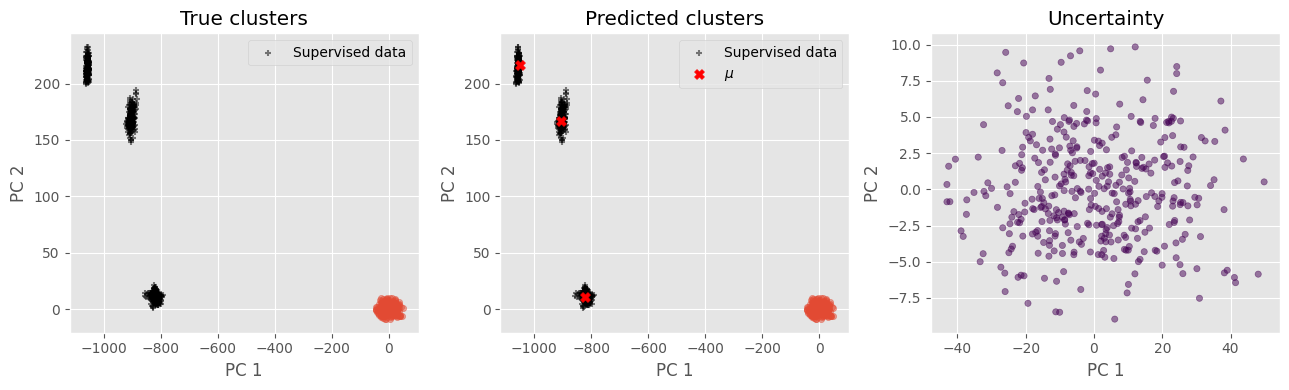

In [46]:
# Transform data to first two principal components for plotting
pca = PCA(n_components=2)
U_pca = pca.fit_transform(new_feat_mat.to_numpy())
X_pca = pca.transform(feat_mat.to_numpy())
mu_pca = pca.transform(mu)

uncertainty = 1 - gamma_resp.max(axis=1)

with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
    ax[0].scatter(U_pca[:, 0], U_pca[:, 1], alpha=0.5, s=20)  # , c=classes_gt)
    ax[0].scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        marker="+",
        c="k",
        alpha=0.5,
        s=20,
        label="Supervised data",
    )
    ax[0].set_title("True clusters")
    ax[1].scatter(U_pca[:, 0], U_pca[:, 1], alpha=0.5, s=20)  # , c=labels_pred)
    ax[1].scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        marker="+",
        c="k",
        alpha=0.5,
        s=20,
        label="Supervised data",
    )
    ax[1].scatter(
        mu_pca[:, 0],
        mu_pca[:, 1],
        marker="X",
        c="r",
        alpha=1,
        s=50,
        label=r"$\mu$",
    )
    ax[1].set_title("Predicted clusters")
    ax[2].scatter(U_pca[:, 0], U_pca[:, 1], c=uncertainty, alpha=0.5, s=20)
    ax[2].set_title("Uncertainty")
    for axi in ax:
        axi.set_xlabel("PC 1")
        axi.set_ylabel("PC 2")
    for axi in ax[:2]:
        axi.legend(loc="best")
    for axi in ax[:2]:
        axi.legend(loc="best")
    fig.tight_layout()
    plt.show()

In [47]:
# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.clustering import TimeSeriesKMeans
# from tslearn.utils import to_time_series_dataset

# np.random.seed(0)
# time = np.linspace(0, 10, 50)
# series = [np.sin(time + shift) for shift in np.linspace(0, 3, 10)]
# dataset = to_time_series_dataset(series)

# scaler = TimeSeriesScalerMeanVariance()
# dataset_scaled = scaler.fit_transform(dataset)

# model = TimeSeriesKMeans(n_clusters=3, metric="dtw", random_state=0)
# labels = model.fit_predict(dataset_scaled)

# print("Cluster Labels (Shape-Based):", labels)

## Lasa

In [48]:
resample_num = 2**10
print(f"Resampling to {resample_num} data points")
smoothing_factor = 0

Resampling to 1024 data points


In [49]:
def smooth_arr(arr, nb_points=256, smoothing_factor=0):
    index_ori = np.arange(start=0, stop=arr.shape[0])
    new_index = np.linspace(start=0, stop=arr.shape[0], num=nb_points)
    arr_smooth = make_splrep(x=index_ori, y=arr, s=smoothing_factor)(new_index)
    return arr_smooth

In [50]:
datasets = [lasa.DataSet.heee, lasa.DataSet.Line, lasa.DataSet.Saeghe]
X = None
classes_gt = None
for idx, data in enumerate(datasets):
    # dt = data.dt
    demos = data.demos
    demo_id = 0
    demo = demos[demo_id]
    pos = demo.pos.T
    pos_resampled = smooth_arr(
        arr=pos, nb_points=resample_num, smoothing_factor=smoothing_factor
    )
    # pos_resampled = pos
    if X is None:
        X = np.hstack((np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled))
        classes_gt = np.ones((pos_resampled.shape[0],), dtype=int) * idx
    else:
        # dist_from_last_point = np.abs(X[-1, :] - pos_resampled[0, :])
        pos_with_time = np.hstack(
            (np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled)
        )
        # X = np.vstack((X, pos_resampled - dist_from_last_point))
        X = np.vstack((X, pos_with_time))
        classes_gt = np.hstack(
            (classes_gt, np.ones(pos_resampled.shape[0], dtype=int) * idx)
        )
# X = np.hstack((np.arange(X.shape[0])[:, np.newaxis], X))
print(X.shape)
print(classes_gt.shape)
dataset = pd.DataFrame(
    {
        "t": X[:, 0],
        "pos_x": X[:, 1],
        "pos_y": X[:, 2],
        "y_cls": classes_gt,
    }
)
dataset

(3072, 3)
(3072,)


,t,pos_x,pos_y,y_cls
0,0.0,-31.414643,18.078238,0
1,1.0,-31.414425,18.078527,0
2,2.0,-31.413891,18.079220,0
3,3.0,-31.413022,18.080319,0
4,4.0,-31.411800,18.081830,0
...,...,...,...,...
3067,1019.0,0.001816,0.001816,2
3068,1020.0,0.000857,0.000857,2
3069,1021.0,0.000250,0.000250,2
3070,1022.0,-0.000002,-0.000002,2


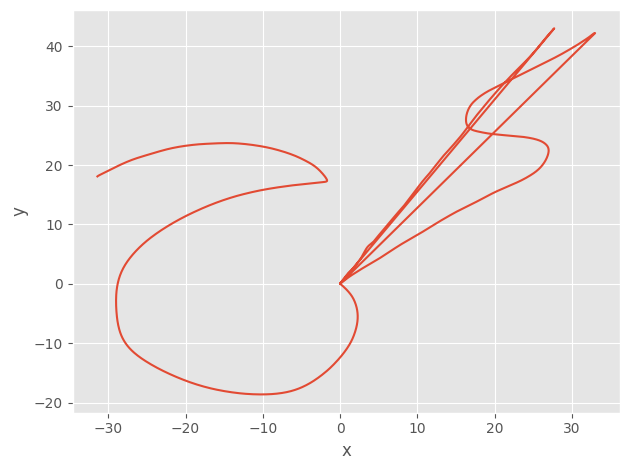

In [51]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.plot(dataset.pos_x, dataset.pos_y)  # , c=blobs[1], alpha=0.5, s=20)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.tight_layout()
    plt.show()

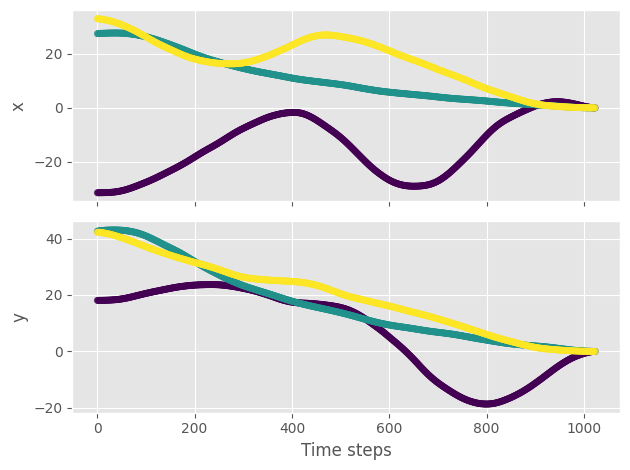

In [52]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(2, 1, sharex=True)
    ax[0].scatter(dataset.t, dataset.pos_x, c=dataset.y_cls, alpha=0.5, s=20)
    ax[1].scatter(dataset.t, dataset.pos_y, c=dataset.y_cls, alpha=0.5, s=20)
    ax[0].set_ylabel("x")
    ax[1].set_ylabel("y")
    ax[1].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [53]:
dataset[["pos_x", "pos_y"]]

,pos_x,pos_y
0,-31.414643,18.078238
1,-31.414425,18.078527
2,-31.413891,18.079220
3,-31.413022,18.080319
4,-31.411800,18.081830
...,...,...
3067,0.001816,0.001816
3068,0.000857,0.000857
3069,0.000250,0.000250
3070,-0.000002,-0.000002


In [54]:
# scaler = TimeSeriesScalerMeanVariance()
# ds_scaled = np.squeeze(scaler.fit_transform(dataset[["pos_x", "pos_y"]]))
# ds_scaled.shape

In [55]:
windows = sliding_window(
    series=dataset[["pos_x", "pos_y"]], window_size=window_size, step=window_step
)
windows.shape

(609, 30, 2)

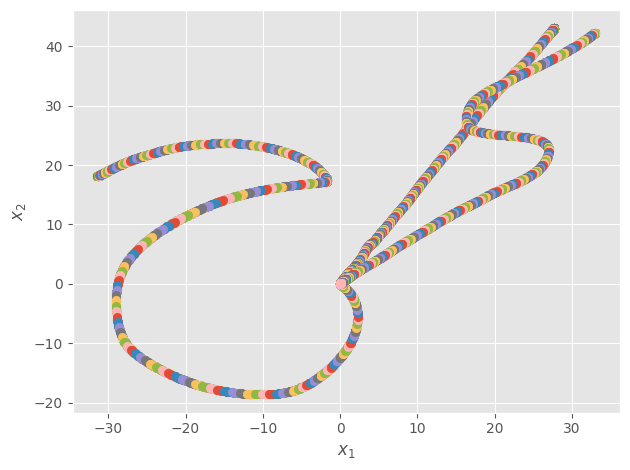

In [56]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

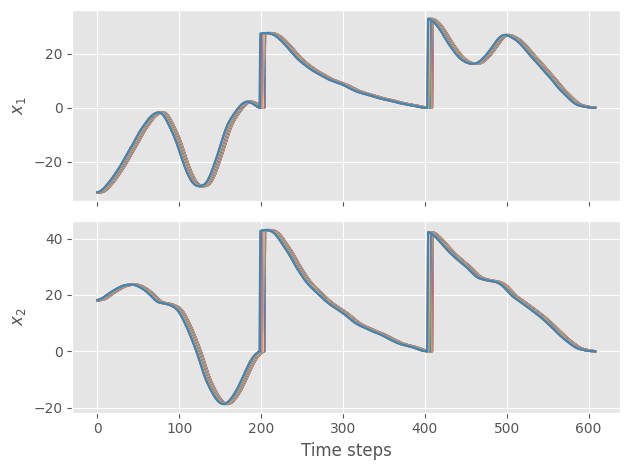

In [57]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[1]):
            ax[idx].plot(windows[:, jdx, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [58]:
feat_mat = extract_features(windows)
feat_mat.shape

(609, 33)

In [59]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,29511.413987,9859.901692,1.484796e+03,2.000071,0.062915,0.864123,-12447.495742,0.757064,0.693270,-0.408358,...,0.0,0.0,0.0,1.0,25.616178,0.070809,0.817110,0.604663,66.492830,-3.739532
1,29447.423608,9891.852450,1.484653e+03,2.000136,0.062915,0.864123,-12382.814038,0.746105,0.693044,-0.455063,...,0.0,0.0,0.0,1.0,25.605753,0.070809,0.796731,0.576548,95.429412,-3.757169
2,29354.844590,9934.651289,1.484348e+03,2.000205,0.062915,0.864123,-12290.825374,0.728735,0.689563,-0.567697,...,0.0,0.0,0.0,1.0,25.589547,0.070809,0.761948,0.584734,134.126117,-3.781829
3,29226.565802,9989.916612,1.483804e+03,2.000270,0.062915,0.864123,-12165.279643,0.707027,0.679202,-0.693856,...,0.0,0.0,0.0,1.0,25.565759,0.070809,0.691083,0.555571,185.629864,-3.815167
4,29053.308746,10060.867066,1.482953e+03,2.000312,0.062915,0.864123,-11997.590093,0.683225,0.668521,-0.831201,...,0.0,0.0,0.0,1.0,25.532390,0.070809,0.604492,0.510438,248.289471,-3.859881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,0.770095,0.770095,2.522219e-13,1.212528,0.889581,0.889581,0.003315,0.632004,0.632004,-1.141718,...,0.0,0.0,0.0,1.0,0.160218,0.054725,0.231266,0.231266,-0.003302,0.391577
605,0.494575,0.494575,2.441450e-13,1.216691,0.848678,0.848678,0.001612,0.631365,0.631365,-1.147044,...,0.0,0.0,0.0,1.0,0.128397,0.054725,0.250295,0.250295,-0.001871,0.445028
606,0.301960,0.301960,2.551431e-13,1.218459,0.914971,0.914971,0.000708,0.634152,0.634152,-1.138508,...,0.0,0.0,0.0,1.0,0.100326,0.053425,0.290737,0.290737,-0.000991,0.516622
607,0.172442,0.172442,2.033677e-13,1.203666,0.885563,0.885563,0.000263,0.638776,0.638776,-1.094932,...,0.0,0.0,0.0,1.0,0.075816,0.051003,0.325268,0.325268,-0.000478,0.624871


In [60]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=dataset.y_cls, window_size=window_size, step=window_step),
        axis=1,
        dtype=int,
    )
)

In [61]:
K_components = len(datasets)
K_components

3

In [62]:
supervised_sample_size = 50
X, Y = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=y_cls_win,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((51, 33),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],

In [63]:
# supervised_sample_size = 50
# idx_superv = np.random.choice(
#     np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# # Y = classes_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [64]:
# scaler = StandardScaler()
# feat_scaled = scaler.fit_transform(features)
# feat_scaled = pd.DataFrame(feat_scaled)
# # feat_scaled = features
# feat_scaled

In [65]:
# pca = PCA(n_components=2)
# feat_mat_pca = pca.fit_transform(feat_mat)
# X_pca = pca.transform(X)
# feat_mat_pca.shape, X_pca.shape

Iteration 0/300 -- Log-likelihood: -49265.70692483943
Iteration 10/300 -- Log-likelihood: -48014.57669391995
Iteration 20/300 -- Log-likelihood: -34240.743477128264
Iteration 30/300 -- Log-likelihood: -35047.4869102802
Iteration 40/300 -- Log-likelihood: -35047.305718506635
Iteration 50/300 -- Log-likelihood: -35047.30322967468

--- Converged at iteration 59 ---



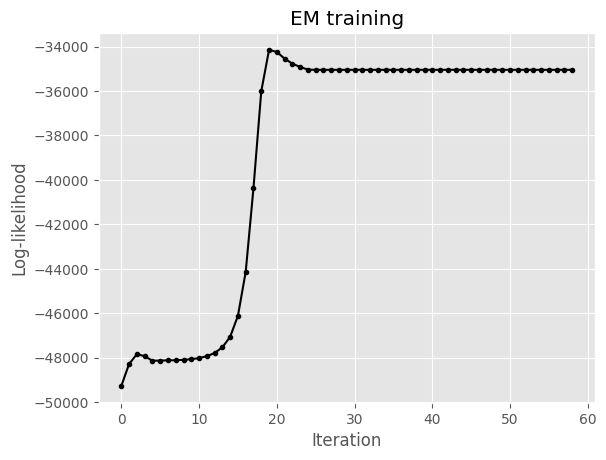

In [67]:
reg_coef = 5e-1
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [68]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 6.80424936e+03,  6.52010343e+03,  6.15334410e+02,
          1.65387414e+00,  2.68445695e-01,  4.73439980e-01,
         -8.64214010e+02,  6.68838644e-01,  6.45980755e-01,
         -4.25436650e-01, -5.25997617e-01,  5.41487905e-01,
          5.51542768e-01,  1.23976459e+01,  1.24142470e+01,
          1.31293220e+01,  1.32048894e+01,  2.05111470e+01,
          9.66270775e-03, -1.53806653e-02,  4.46601327e-03,
          6.94160004e-03,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  8.55839399e-01,
          1.34492251e+01,  5.64081020e-02,  9.86356963e-02,
          9.96284198e-02, -1.71337709e+02,  4.58296944e-01],
        [ 7.77550003e+03,  1.33286116e+04,  1.80309260e+02,
          1.79688936e+00,  4.04191055e-01,  3.31109774e-01,
          8.91907148e+03,  6.49915970e-01,  6.40734132e-01,
         -1.06954512e+00, -1.09402271e+00,  6.27846395e-01,
          6.31464664e-01,  1.45719012e+01,  1.45245996e+01,
          1.43184116e+01,  1.44049655e+

In [69]:
# np.round(gmm.means_), np.round(gmm.covariances_)

In [70]:
y_cls_win, clust_labels_pred

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [71]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: -0.09633668984410323
Completeness: 0.46263402697973954
Fowlkes-Mallows index: 0.5672540453270477
Homogeneity: 0.2924385403944133
Mutual Information: 0.3212480936542268
Adjusted mutual information: 0.35597066235260827
Normalized Mutual Information: 0.3583550123062672
Rand index: 0.5636018926626912
Adjusted rand index: 0.191411434277539
V-measure: 0.3583550123062672


In [72]:
# uncertainty = 1 - gamma_resp.max(axis=1)

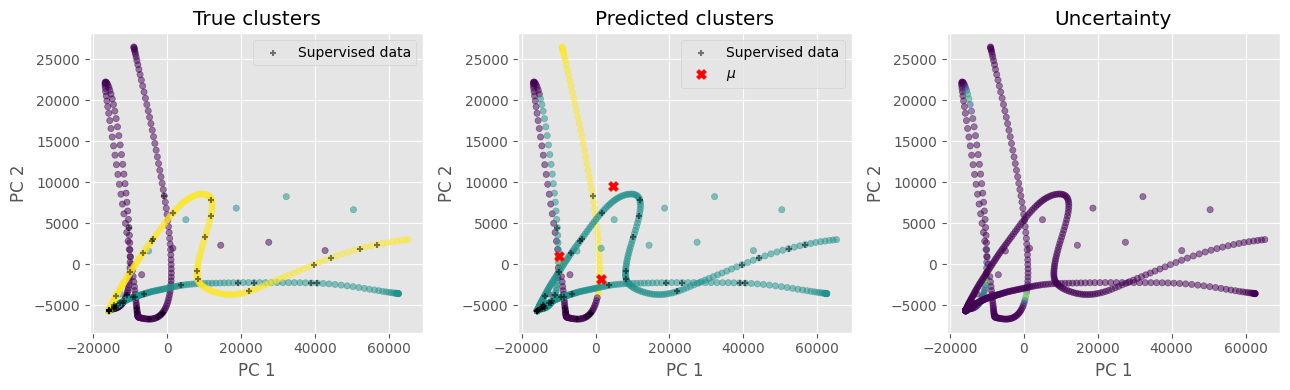

In [73]:
plot_cluster_res(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=y_cls_win,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

## Synthetic hierarchical (toy) data

In [74]:
# def plot_gaussian_hmm(
#     hmm, params, emissions, states, title="Emission Distributions", alpha=0.25
# ):
#     lim = 1.1 * abs(emissions).max()
#     XX, YY = jnp.meshgrid(jnp.linspace(-lim, lim, 100), jnp.linspace(-lim, lim, 100))
#     grid = jnp.column_stack((XX.ravel(), YY.ravel()))

#     plt.figure()
#     for k in range(hmm.num_states):
#         lls = hmm.emission_distribution(params, k).log_prob(grid)
#         plt.contour(
#             XX, YY, jnp.exp(lls).reshape(XX.shape), cmap=white_to_color_cmap(COLORS[k])
#         )
#         plt.plot(
#             emissions[states == k, 0],
#             emissions[states == k, 1],
#             "o",
#             mfc=COLORS[k],
#             mec="none",
#             ms=3,
#             alpha=alpha,
#         )

#     plt.plot(emissions[:, 0], emissions[:, 1], "-k", lw=1, alpha=alpha)
#     plt.xlabel("$y_1$")
#     plt.ylabel("$y_2$")
#     plt.title(title)
#     plt.gca().set_aspect(1.0)
#     plt.tight_layout()

In [75]:
def generate_two_level_hmm_sequence(
    seq_length,
    n_meta,
    n_sub,
    obs_dim,
    A_meta,
    A_sub,
    pi_meta,
    pi_sub,
    means,
    covariances,
    seed=None,
):
    """
    Generate sequence from a 2-level HMM.

    Parameters:
    - A_meta: (n_meta, n_meta) meta-state transition matrix
    - A_sub: (n_meta, n_sub, n_sub) sub-state transition (depends on meta)
    - pi_meta: (n_meta,) initial meta distribution
    - pi_sub: (n_meta, n_sub) initial sub distribution given meta
    - means: (n_meta, n_sub) observation means
    - covariances: (n_meta, n_sub, obs_dim, obs_dim) covariance matrices
    """
    rng = np.random.default_rng(seed)

    # Initialize arrays
    meta_states = np.zeros(seq_length, dtype=int)
    sub_states = np.zeros(seq_length, dtype=int)
    observations = np.zeros((seq_length, obs_dim))

    # Sample initial states
    meta_states[0] = rng.choice(n_meta, p=pi_meta)
    sub_states[0] = rng.choice(n_sub, p=pi_sub[meta_states[0]])

    # Generate first observation (multi-dimensional)
    observations[0] = rng.multivariate_normal(
        mean=means[meta_states[0], sub_states[0]],
        cov=covariances[meta_states[0], sub_states[0]],
    )

    # Generate rest of the sequence
    for t in range(1, seq_length):
        # Meta-state transition (depends only on previous meta)
        meta_states[t] = rng.choice(n_meta, p=A_meta[meta_states[t - 1]])

        # Check if meta-state changed
        if meta_states[t] != meta_states[t - 1]:
            # RESET: Sample sub-state from initial distribution
            sub_states[t] = rng.choice(n_sub, p=pi_sub[meta_states[t]])
        else:
            # Normal transition within same meta-state
            sub_states[t] = rng.choice(
                n_sub, p=A_sub[meta_states[t], sub_states[t - 1]]
            )

        # Multi-dimensional observation (depends on current meta and sub)
        observations[t] = rng.multivariate_normal(
            mean=means[meta_states[t], sub_states[t]],
            cov=covariances[meta_states[t], sub_states[t]],
            # size=(obs_dim),
        )

    return meta_states, sub_states, observations

In [76]:
n_meta = 3
n_sub = 4
obs_dim = 2

# Transition matrices
A_meta = np.array(
    [
        [0.8, 0.1, 0.1],  # from meta 0
        [0.1, 0.8, 0.1],  # from meta 1
        [0.1, 0.1, 0.8],  # from meta 2
    ]
)

# Sub-state transitions for each meta-state
A_sub = np.zeros((n_meta, n_sub, n_sub))
# Meta 0: tends to stay in same sub-state
A_sub[0] = np.array(
    [
        [0.7, 0.1, 0.1, 0.1],
        [0.1, 0.7, 0.1, 0.1],
        [0.1, 0.1, 0.7, 0.1],
        [0.1, 0.1, 0.1, 0.7],
    ]
)
# Meta 1: tends to increase sub-state
A_sub[1] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)
# Meta 2: tends to decrease sub-state
# A_sub[2] = np.array(
#     [
#         [0.4, 0.0, 0.0, 0.6],
#         [0.6, 0.4, 0.0, 0.0],
#         [0.0, 0.6, 0.4, 0.0],
#         [0.0, 0.0, 0.6, 0.4],
#     ]
# )
# Meta 2: tends to increase sub-state
A_sub[2] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)

# Initial distributions
pi_meta = np.array([0.34, 0.33, 0.33])  # uniform-ish
# pi_sub = np.array(
#     [
#         [0.4, 0.3, 0.2, 0.1],  # given meta 0
#         [0.1, 0.2, 0.3, 0.4],  # given meta 1
#         [0.25, 0.25, 0.25, 0.25],  # given meta 2
#     ]
# )
pi_sub = np.array(
    [
        [0.6, 0.1, 0.2, 0.1],  # given meta 0
        [0.2, 0.6, 0.1, 0.1],  # given meta 1
        [0.0, 0.2, 0.6, 0.2],  # given meta 2
    ]
)


# Multi-dimensional observation parameters
means = np.zeros((n_meta, n_sub, obs_dim))
covariances = np.zeros((n_meta, n_sub, obs_dim, obs_dim))

# # Make means distinct for different meta-sub combinations
# for m in range(n_meta):
#     for s in range(n_sub):
#         means[m, s] = m * 10 + s * 2  # e.g., meta0: 0,2,4,6; meta1: 10,12,14,16; etc.

# Define different (meta, sub) pairs to have distinct 2D Gaussian distributions
for m in range(n_meta):
    for s in range(n_sub):
        # Different centers for each state
        means[m, s, :] = [
            m * 10 + s * 2,
            m * 5 + s * 1.5,
            # m * 15 + s * 2.5,
            # m * 20 + s * 1,
            # m * 0 + s * 0,
        ]

        # Different covariance structures
        if m == 0:  # Meta 0: isotropic
            covariances[m, s] = np.eye(obs_dim) * (s + 1)
        elif m == 1:  # Meta 1: correlated
            covariances[m, s] = np.array([[2.0, 0.8], [0.8, 1.0]]) * (s + 1)
        else:  # Meta 2: anti-correlated
            covariances[m, s] = np.array([[2.0, -0.5], [-0.5, 1.0]]) * (s + 1)

In [77]:
# Generate sequence
meta_states, sub_states, observations = generate_two_level_hmm_sequence(
    seq_length=seq_length,
    n_meta=n_meta,
    n_sub=n_sub,
    obs_dim=obs_dim,
    A_meta=A_meta,
    A_sub=A_sub,
    pi_meta=pi_meta,
    pi_sub=pi_sub,
    means=means,
    covariances=covariances,
    seed=seed,
)

print(f"Meta states:  {meta_states}")
print(f"Sub states:   {sub_states}")
print(f"Observations:\n{np.round(observations[:10, :], 2)}\n [...]")

Meta states:  [2 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 1 1 0 0 0 0 2 2 0 0 0 0 0 0 0 2 2 2
 2 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 2 2 2 2 2 2 2 1 2 1 0 0 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 2 1 0 0 0 0 0 0 0 0 0
 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 2 2 2 2 2 0 0 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 0 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 2
 2 2 2 1 1 2 2 2 2 2 2 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2
 2 2 1 1 1 2 2 2 2 2 2 2 2 2 2 2 1 2 2 1 1 2 2 2 2 2 2 1 0 0 1 0 0 0 0 1 1
 2 2 2 0 0 0 0 0 1 0 0 0 0 0 2 2 2 2 2 2 2 1 1 2 2 2 1 1 2 2 0 0 0 1 1 2 2
 2 2 2 2 2 2 2 0 2 2 2 2 2 1 1 1 0 2 2 2 2 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 0 0 1 1 1 0 0 0 1 1 1 1 0 0 0 1 1
 1 1 1 1 1 0 0 0 0 2 2 1 1 1 1 2 2 2 2 2 0 0 0 0 0 0 0 0 1 2 1 0 1 1 1 1 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 0 0 0 0 1 1 1 1 0 0 1
 1 1 2 2 2 

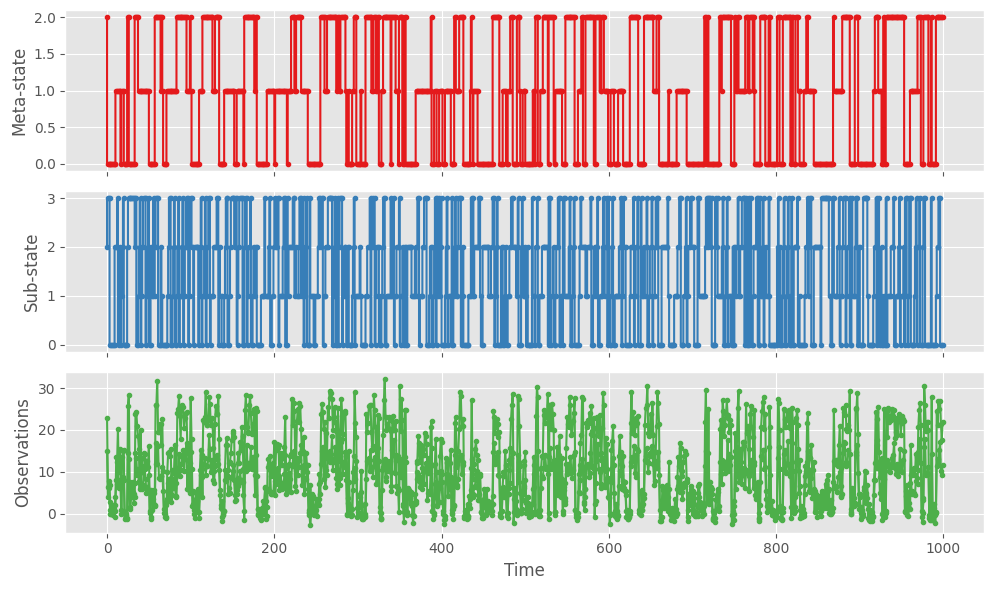

In [78]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["Set1"].colors
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 6))
    axes[0].step(meta_states, ".-", c=cmap[0])
    axes[0].set_ylabel("Meta-state")
    axes[1].step(sub_states, ".-", c=cmap[1])
    axes[1].set_ylabel("Sub-state")
    axes[2].plot(observations, ".-", c=cmap[2])
    axes[2].set_ylabel("Observations")
    axes[2].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

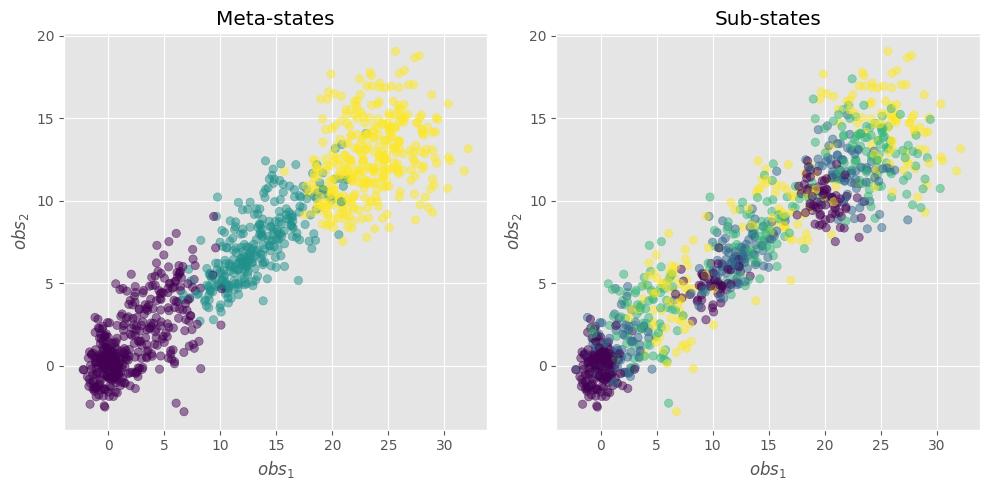

In [79]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=meta_states)
    ax[1].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=sub_states)
    ax[0].set_title("Meta-states")
    ax[1].set_title("Sub-states")
    for axi in ax:
        axi.set_xlabel(f"$obs_1$")
        axi.set_ylabel(f"$obs_2$")
    fig.tight_layout()
    plt.show()

In [80]:
windows = sliding_window(series=observations, window_size=window_size, step=window_step)
windows.shape

(195, 30, 2)

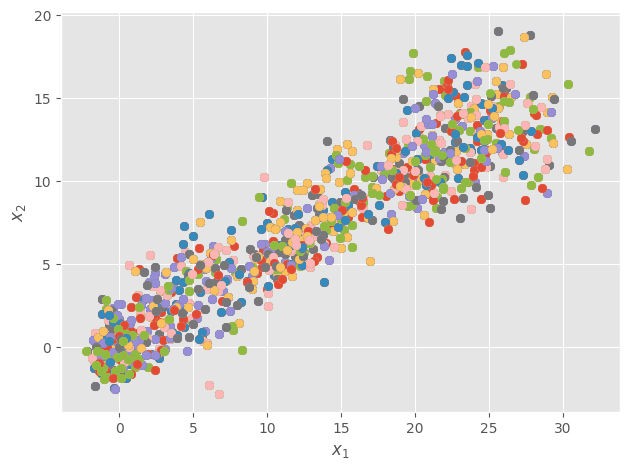

In [81]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

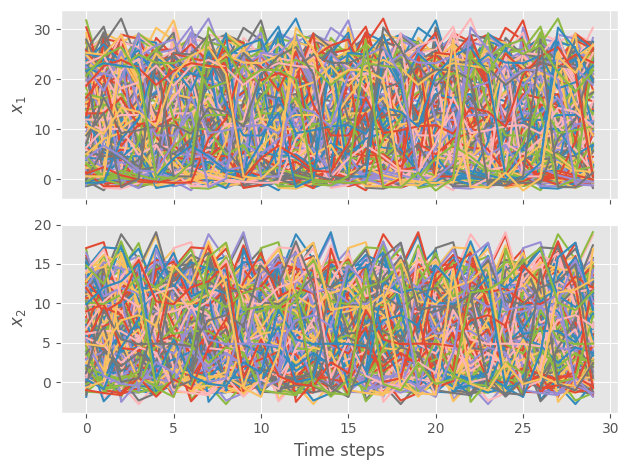

In [82]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            ax[idx].plot(windows[jdx, :, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [83]:
feat_mat = extract_features(windows)
feat_mat.shape

(195, 33)

In [84]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,4130.254606,1324.152086,120.177532,-0.076766,0.837885,0.585189,312.359301,5.912238,6.078388,-0.169950,...,0.0,0.0,0.0,1.0,9.534505,0.684779,0.813734,0.677970,253.420074,1.075001
1,4177.164916,1321.981566,121.209101,-0.082354,0.902984,0.568303,150.498710,5.904165,6.129242,-0.126826,...,0.0,0.0,0.0,1.0,9.573528,0.738404,0.836211,0.628694,276.153160,1.051004
2,5874.872252,1793.323252,157.153129,-0.066080,0.904620,0.505846,694.785497,5.920269,6.382019,-0.821978,...,0.0,0.0,0.0,1.0,11.305010,0.601580,0.288398,0.134967,53.274242,0.811897
3,6053.506731,1844.315545,161.310459,0.119722,0.914853,0.575368,899.013232,5.869495,6.313997,-0.723876,...,0.0,0.0,0.0,1.0,11.473028,0.601580,0.204877,0.070589,534.081286,0.783019
4,6065.606353,1855.749684,164.433797,0.141727,0.920164,0.623838,927.376053,5.683516,5.998427,-0.500073,...,0.0,0.0,0.0,1.0,11.490109,0.750967,0.226249,0.150256,-20.856898,0.749856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,7597.330908,2568.447471,181.313904,0.198537,0.835580,0.739012,1474.178676,5.077354,5.278815,-1.266188,...,0.0,0.0,0.0,1.0,13.016514,0.579818,0.169482,0.234366,1396.152920,0.795310
191,6938.593992,2247.060491,175.299858,0.142257,0.869662,0.660605,1123.749707,4.955482,5.027056,-1.114724,...,0.0,0.0,0.0,1.0,12.373126,0.610260,0.249619,0.365479,889.873796,0.867524
192,7638.363102,2424.599222,178.782371,0.237219,0.859438,0.775430,1251.696687,6.016608,5.946950,-1.289717,...,0.0,0.0,0.0,1.0,12.950523,0.598837,0.084934,0.216675,685.980922,0.910124
193,8806.821623,2700.917065,189.660018,-0.055620,0.790430,0.870127,1043.979523,5.769665,5.739237,-1.651343,...,0.0,0.0,0.0,1.0,13.849030,0.851050,-0.086484,0.009621,-280.768682,0.948276


In [85]:
# feat_mat = pd.DataFrame(observations)
# feat_mat

### Meta-states clustering

In [86]:
K_components = n_meta

In [87]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=meta_states, window_size=window_size, step=window_step),
        axis=1,
    )
).astype(int)
y_cls_win

array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [88]:
# supervised_sample_size = 20
# idx_superv = np.random.choice(
#     np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
# )
# Y = np.zeros((len(idx_superv), K_components))
# for idxi, idx_val in enumerate(idx_superv):
#     Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# # Y = classes_gt[idx_superv]
# X = feat_mat.iloc[idx_superv, :]
# X.shape, Y

In [89]:
supervised_sample_size = 15
X, Y = select_supervised_data(
    total_sample_size=supervised_sample_size,
    labels_gt=y_cls_win,
    K_components=K_components,
    U=feat_mat.to_numpy(),
)
X.shape, Y

((15, 33),
 array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.]]))

Iteration 0/300 -- Log-likelihood: -6736.961421445263
Iteration 10/300 -- Log-likelihood: -35083519015.86773
Iteration 20/300 -- Log-likelihood: -35083628148.20494
Iteration 30/300 -- Log-likelihood: -35083628147.985146
Iteration 40/300 -- Log-likelihood: -35083628147.98353

--- Converged at iteration 43 ---



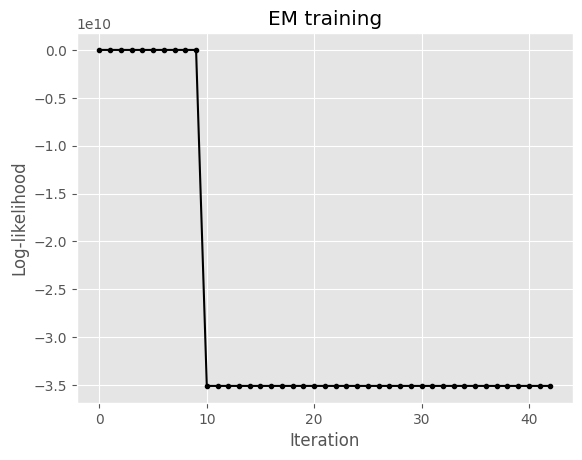

In [90]:
reg_coef = 1e-2
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X,
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [91]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 8.79348598e+03,  2.65826408e+03,  2.06170426e+02,
          3.58440581e-01,  8.53452418e-01,  7.93018030e-01,
          1.66389988e+03,  5.01942439e+00,  5.37308405e+00,
         -9.81465428e-01, -7.58932067e-01,  6.33653542e-01,
          6.44596045e-01,  9.34627754e+00,  8.45928090e+00,
          7.82629658e+00,  7.62457156e+00,  6.87234753e+00,
         -8.04191946e-03, -1.35933471e-02, -3.97711583e-03,
          2.65728288e-03,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  1.05178145e+00,
          1.40351087e+01,  7.89597574e-01, -1.91217852e-01,
         -1.15583609e-01, -4.60010551e+00,  7.98853385e-01],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+

In [92]:
y_cls_win, clust_labels_pred

(array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 1, 0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2,
        0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 0

In [93]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.37821752919049667
Completeness: 0.37447138787240547
Fowlkes-Mallows index: 0.8167028294510826
Homogeneity: 0.39885765435913956
Mutual Information: 0.20457546691134648
Adjusted mutual information: 0.3796338226203612
Normalized Mutual Information: 0.3862800211418378
Rand index: 0.7468146973301613
Adjusted rand index: 0.42028651283227225
V-measure: 0.38628002114183774


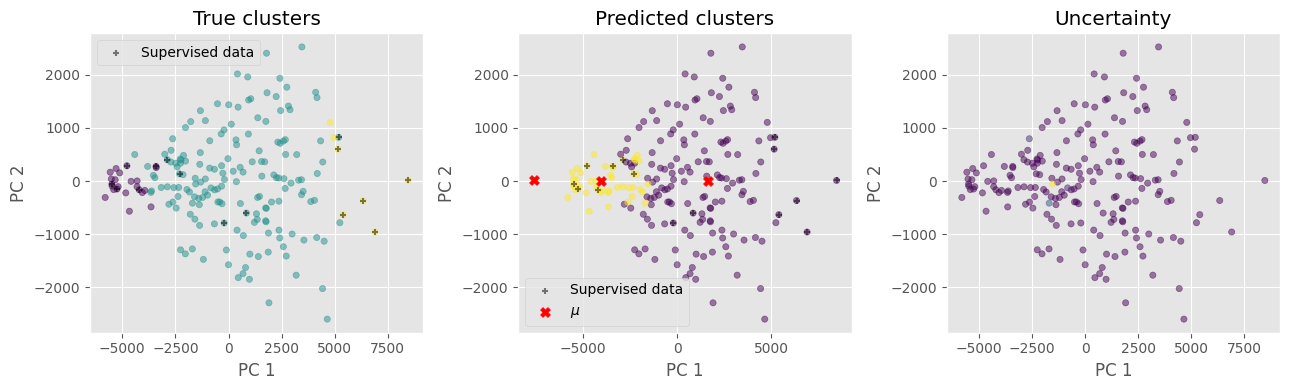

In [94]:
plot_cluster_res(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=y_cls_win,
    # labels_gt=meta_states,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)

### Sub-states clustering

In [95]:
K_components = n_sub

In [96]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=sub_states, window_size=window_size, step=window_step),
        axis=1,
    )
).astype(int)
y_cls_win

array([1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 1, 1, 2, 2, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [97]:
supervised_sample_size = 30
idx_superv = np.random.choice(
    np.arange(y_cls_win.shape[0]), size=supervised_sample_size, replace=False
)
Y = np.zeros((len(idx_superv), K_components))
for idxi, idx_val in enumerate(idx_superv):
    Y[idxi, int(y_cls_win[int(idx_val)])] = 1
# Y = classes_gt[idx_superv]
X = feat_mat.iloc[idx_superv, :]
X.shape, Y

((30, 33),
 array([[0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.]]))

Iteration 0/300 -- Log-likelihood: -8394.411108425174
Iteration 10/300 -- Log-likelihood: -63273997185.61397
Iteration 20/300 -- Log-likelihood: -63273997159.22075
Iteration 30/300 -- Log-likelihood: -63273997159.03433
Iteration 40/300 -- Log-likelihood: -63273997159.0335

--- Converged at iteration 43 ---



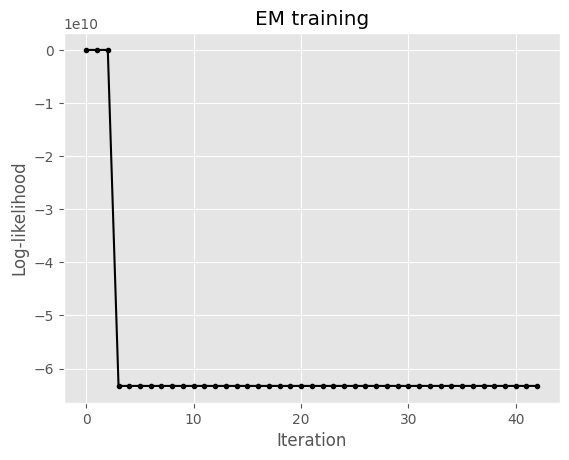

In [98]:
reg_coef = 1e-2
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    K_components=K_components,
    U=feat_mat.to_numpy(),
    X=X.to_numpy(),
    Y=Y,
    beta=beta,
    reg_coef=reg_coef,
    seed=seed,
    allow_singular=False,
)

In [99]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

(array([[ 5.68311082e+03,  1.76513485e+03,  1.60042325e+02,
          1.34887004e-01,  9.68527148e-01,  8.01752684e-01,
          5.85028567e+02,  5.27722179e+00,  5.77911274e+00,
         -4.95847829e-01, -5.11456832e-01,  6.74152340e-01,
          6.81188290e-01,  8.78593599e+00,  7.42316941e+00,
          9.70515118e+00,  8.78735931e+00,  5.33474417e+00,
          1.59690844e-02, -1.25526687e-02,  2.08110563e-02,
          4.90398074e-03,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  1.12093668e+00,
          1.15844141e+01,  8.38027195e-01,  5.03144627e-01,
          4.86736094e-01, -4.21190015e+01,  1.06462105e+00],
        [ 8.72380650e+03,  2.64079043e+03,  2.01933511e+02,
          3.26774113e-01,  8.36394138e-01,  7.94887909e-01,
          1.52903032e+03,  4.83071367e+00,  5.15407471e+00,
         -1.18414969e+00, -9.09262319e-01,  6.16297261e-01,
          6.28802443e-01,  8.83833770e+00,  8.61631787e+00,
          7.82190165e+00,  7.51280958e+

In [100]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.37023460079312026
Completeness: 0.0012917956511720448
Fowlkes-Mallows index: 0.47737920766211567
Homogeneity: 0.001878401269223752
Mutual Information: 0.0012146670246859503
Adjusted mutual information: -0.0051066452668511965
Normalized Mutual Information: 0.001530826413418094
Rand index: 0.4935765265662173
Adjusted rand index: 0.0013649889107878916
V-measure: 0.001530826413418094


In [101]:
# uncertainty = 1 - gamma_resp.max(axis=1)

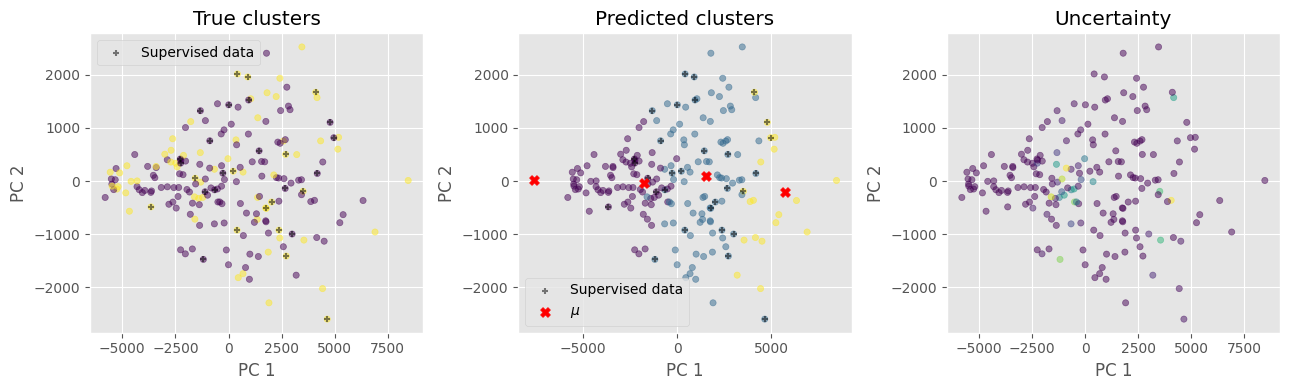

In [102]:
plot_cluster_res(
    U=feat_mat,
    X=X,
    Y=Y,
    labels_gt=y_cls_win,
    labels_pred=clust_labels_pred,
    gamma_resp=gamma_resp,
    mu=mu,
)